# 04 · Multi-Agent (Supervisor pattern)

**Idea:** Several specialised agents, each with its own prompt and tools, coordinated by a **supervisor**
that decides *who acts next*.

```
            +--> researcher --+
START -> supervisor           +--> back to supervisor --> ... --> END
            +--> writer ------+
```

Each worker is a mini-agent made with `create_agent` (LangChain's one-line agent factory).
The supervisor is a node that returns a `Command(goto=...)` — routing and state update in one object.

In [1]:
# --- Model setup -------------------------------------------------------------
# 1) Ollama must be running   ->  `ollama serve`  (the desktop app does this for you)
# 2) Pull the models once     ->  `ollama pull llama3.1`  and  `ollama pull qwen3:0.6b`
from langchain_ollama import ChatOllama

# llama3.1 (8B): our main "brain" - good at tool calling & structured output.
llm = ChatOllama(model="llama3.1", temperature=0)

# qwen3:0.6b: a tiny, very fast model - great for cheap jobs (classify, summarise, route).
# reasoning=False hides qwen3's <think> block so `.content` is just the answer.
small_llm = ChatOllama(model="qwen3:0.6b", temperature=0, reasoning=False)

In [48]:
from typing import Literal
from pydantic import BaseModel
from langchain.agents import create_agent
from langchain.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.types import Command

### 1 · Two specialised workers

In [49]:
@tool
def search_facts(topic: str) -> str:
    """Look up facts about a topic."""
    # Fake "search engine" so the demo works offline. Swap for a real search tool in practice.
    facts = {
        "electric cars": "EVs have fewer moving parts, lower running costs, and zero tailpipe emissions. "
                         "Charging infrastructure and battery cost are the main hurdles.",
    }
    return facts.get(topic.lower(), "EVs are growing fast worldwide; batteries are getting cheaper.")

researcher = create_agent(
    llm, tools=[search_facts],
    system_prompt="You are a researcher. Use the search_facts tool, then reply with 3 bullet-point facts.",
)
writer = create_agent(
    llm, tools=[],
    system_prompt="You are a writer. Turn the facts in the conversation into a friendly 3-sentence paragraph.",
)

### 2 · The supervisor

It reads the conversation and picks the next worker with *structured output* (a `Literal` = only valid choices).

In [65]:
class Route(BaseModel):
    next: Literal["researcher", "writer", "FINISH"]

SUPERVISOR_PROMPT = """You manage two workers: researcher (finds facts) and writer (writes the final text).
Rules: 1) If no facts exist yet -> researcher.  2) If facts exist but no final paragraph -> writer.
3) If the writer has produced a paragraph -> FINISH."""

SUPERVISOR_PROMPT = """You manage two workers: researcher (finds facts) and writer (writes the final text).

Look at the conversation history:
- Look at the VERY LAST message in the conversation history:
  - If the last message is from 'WRITER', output 'FINISH'.
  - If the last message is from 'RESEARCHER', output 'writer'.
  - If there are no messages from 'RESEARCHER' yet, output 'researcher'."""

decision = llm.with_structured_output(Route).invoke(
        [SystemMessage(SUPERVISOR_PROMPT)] + [HumanMessage("Write a short paragraph about the pros and cons of electric cars.")]
    )

print(decision)

data = {'messages': [HumanMessage(content='Write a short paragraph about the pros and cons of electric cars.', additional_kwargs={}, response_metadata={}, id='9ca1cfd6-1c6d-426b-b15f-3c4b0fa0435e'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.1', 'created_at': '2026-10-01T12:13:18.405709Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1012442000, 'load_duration': 6495292, 'prompt_eval_count': 186, 'prompt_eval_duration': 52793000, 'eval_count': 19, 'eval_duration': 926208000, 'logprobs': None, 'model_name': 'llama3.1', 'model_provider': 'ollama'}, id='lc_run--01a0f762-1cd0-7fb2-a3f1-60094b401fd0-0', tool_calls=[{'name': 'search_facts', 'args': {'topic': 'electric cars'}, 'id': 'a6dcb83a-d6c9-44d0-9364-87a273f0ca74', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 186, 'output_tokens': 19, 'total_tokens': 205}), ToolMessage(content='EVs have fewer moving parts, lower running costs, and zero tailpipe emissions. Charging infrastructure and battery cost are the main hurdles.', name='search_facts', id='7db7dce7-01c0-47fd-bdbc-d94b39856edf', tool_call_id='a6dcb83a-d6c9-44d0-9364-87a273f0ca74'), AIMessage(content='Based on the search results, here are three bullet-point facts about the pros and cons of electric cars:\n\n* **Pros:**\n\t+ Fewer moving parts, resulting in lower maintenance costs\n\t+ Zero tailpipe emissions, reducing air pollution and greenhouse gas emissions\n* **Cons:**\n\t+ Higher upfront costs due to the cost of the battery\n\t+ Limited charging infrastructure in some areas, making long-distance travel more difficult', additional_kwargs={}, response_metadata={'model': 'llama3.1', 'created_at': '2026-10-01T12:13:22.90688Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4494625459, 'load_duration': 6513250, 'prompt_eval_count': 146, 'prompt_eval_duration': 49761000, 'eval_count': 88, 'eval_duration': 4414060000, 'logprobs': None, 'model_name': 'llama3.1', 'model_provider': 'ollama'}, id='lc_run--01a0f762-20ca-7a83-a882-50ab1c908c58-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 146, 'output_tokens': 88, 'total_tokens': 234})]}

decision = llm.with_structured_output(Route).invoke(
        [SystemMessage(SUPERVISOR_PROMPT)] + data["messages"]
    )

print(decision)
 

next='researcher'
next='writer'


In [ ]:
class Route(BaseModel):
    next: Literal["researcher", "writer", "FINISH"]

SUPERVISOR_PROMPTx = """You manage two workers: researcher (finds facts) and writer (writes the final text).
Rules: - Look at the VERY LAST message in the conversation history:
  - If the last message is from 'WRITER', output 'FINISH'.
  - If the last message is from 'RESEARCHER', output 'writer'.
  - If there are no messages from 'RESEARCHER' yet, output 'researcher'.."""

 

def supervisor(state: MessagesState) -> Command[Literal["researcher", "writer", "__end__"]]:
    print(state["messages"])
    print("=========================")
    decision = llm.with_structured_output(Route).invoke(
        [SystemMessage(SUPERVISOR_PROMPT)] + state["messages"]
    )
    print(f"🧭 supervisor -> {decision.next}")
    goto = END if decision.next == "FINISH" else decision.next
    return Command(goto=goto)           # routing decision only, no state change


def make_worker_node(name: str, agent):
    """Wrap an agent as a graph node that reports back to the supervisor."""
    def node(state: MessagesState) -> Command[Literal["supervisor"]]:
        result = agent.invoke({"messages": state["messages"]})
        print(name)
        print("-----------------------")
        print(result)
        reply = result["messages"][-1].content
        print(reply)
        
        # Tag the message with the worker's name so the supervisor knows who said what.
        return Command(goto="supervisor",
                       update={"messages": [HumanMessage(content="Message from "+name+",  "+reply, name=name)]})
    return node

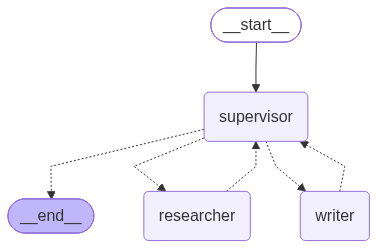

[HumanMessage(content='Write a short paragraph about the pros and cons of electric cars.', additional_kwargs={}, response_metadata={}, id='a8e5593e-745d-4e9a-b3b0-1a0084ca0761')]
🧭 supervisor -> researcher
researcher
-----------------------
{'messages': [HumanMessage(content='Write a short paragraph about the pros and cons of electric cars.', additional_kwargs={}, response_metadata={}, id='a8e5593e-745d-4e9a-b3b0-1a0084ca0761'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.1', 'created_at': '2026-10-01T12:55:15.49038Z', 'done': True, 'done_reason': 'stop', 'total_duration': 971974625, 'load_duration': 3058709, 'prompt_eval_count': 186, 'prompt_eval_duration': 49411000, 'eval_count': 19, 'eval_duration': 898194000, 'logprobs': None, 'model_name': 'llama3.1', 'model_provider': 'ollama'}, id='lc_run--01a0f788-8554-7251-abb2-8c94dc6dea31-0', tool_calls=[{'name': 'search_facts', 'args': {'topic': 'electric cars'}, 'id': '149b86b5-5885-4431-8ac9-359d5af7c4e

In [64]:
builder = StateGraph(MessagesState)
builder.add_node("supervisor", supervisor)
builder.add_node("researcher", make_worker_node("researcher", researcher))
builder.add_node("writer", make_worker_node("writer", writer))
builder.add_edge(START, "supervisor")      # no other edges needed: Command(goto=...) does the routing
graph = builder.compile()
from IPython.display import display, Image

# Visualize the agent's decision-making flow
display(Image(graph.get_graph().draw_mermaid_png()))
result = graph.invoke(
    {"messages": [HumanMessage("Write a short paragraph about the pros and cons of electric cars.")]},
    config={"recursion_limit": 12},        # safety net against infinite supervisor loops
)
print("\n✅ FINAL:\n", result["messages"][-1].content)

### Other multi-agent shapes worth knowing
| Shape | How |
|---|---|
| **Supervisor** (this notebook) | One boss routes to workers |
| **Hierarchical** | A worker is itself a supervisor of a sub-team (compile a graph, use it as a node) |
| **Swarm / Handoff** | Agents pass control directly to each other via tools, no boss (`langgraph-swarm` package) |
| **Network** | Any agent may call any other; most flexible, hardest to debug |

The `langgraph-supervisor` package offers a ready-made `create_supervisor(...)` if you don't want to hand-roll it.